In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
test = pd.read_csv('test_battery_V5.csv')

#
### **🚧 4. 혼잡 / 경로 / 충돌**
* congestion_score → 창고 혼잡도 점수
* max_zone_density → 특정 구역 최대 밀집도
* blocked_path_15m → 막힌 경로 수 (15분)
* near_collision_15m → 충돌 직전 이벤트 수
* aisle_traffic_score → 통로 교통량 점수
* intersection_wait_time_avg → 교차로 평균 대기 시간
* path_optimization_score → 경로 최적화 점수

In [ ]:
test_traffic = test[["congestion_score","max_zone_density","blocked_path_15m",
        "near_collision_15m","aisle_traffic_score",
        "intersection_wait_time_avg","path_optimization_score"]]
test_traffic

,congestion_score,max_zone_density,blocked_path_15m,near_collision_15m,aisle_traffic_score,intersection_wait_time_avg,path_optimization_score
0,16.70,0.0682,0.0,0.0,47.7,1.63,75.5
1,20.04,0.0909,2.0,0.0,45.5,2.39,76.1
2,25.05,0.1136,0.0,2.0,50.3,NaN,91.8
3,16.70,0.1136,1.0,3.0,54.2,1.03,78.7
4,15.03,0.0909,1.0,2.0,47.6,0.87,80.4
...,...,...,...,...,...,...,...
49995,0.00,0.0000,0.0,0.0,6.0,0.00,86.6
49996,0.00,0.0000,0.0,0.0,18.0,0.00,93.7
49997,NaN,0.0556,NaN,0.0,NaN,0.32,89.5
49998,0.00,0.0000,0.0,NaN,14.7,1.59,91.5


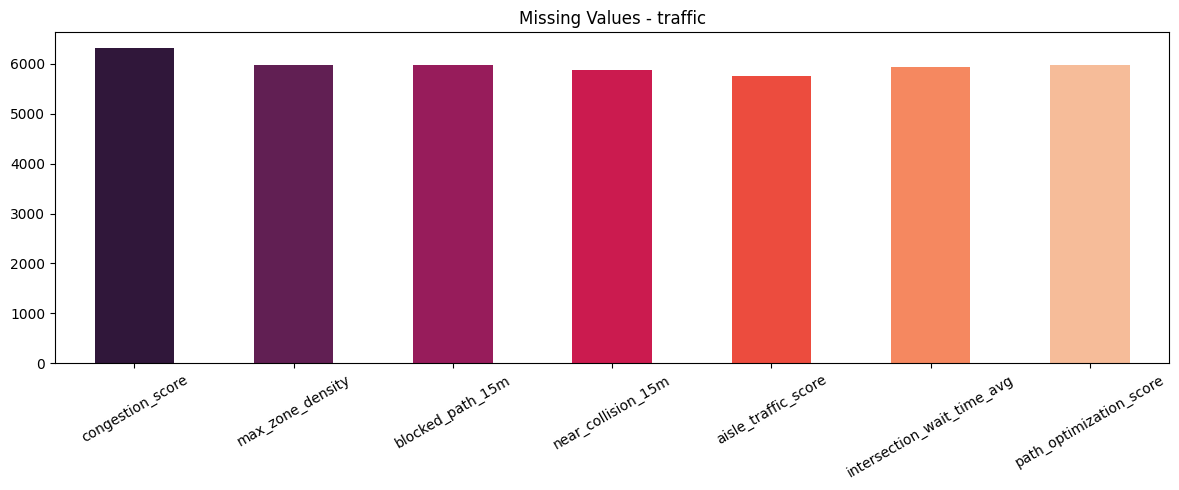

In [ ]:
missing = test_traffic.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - traffic')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

cols = [
    "congestion_score",
    "max_zone_density",
    "blocked_path_15m",
    "near_collision_15m"
]

target = "congestion_score"
features = [c for c in cols if c != target]

# 결측 없는 행으로 학습
train_rf = test_traffic.dropna(subset=cols)

X = train_rf[features]
y = train_rf[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 결측 채우기
mask = test_traffic[target].isna()

test_traffic.loc[mask, target] = model.predict(
    test_traffic.loc[mask, features]
)

/tmp/ipykernel_2349/322227441.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_traffic.loc[mask, target] = model.predict(


In [ ]:
test["congestion_score"] = test_traffic["congestion_score"]

In [ ]:
test[["congestion_score", "blocked_path_15m", "max_zone_density", "near_collision_15m"]].isnull().sum().to_frame(name="NaN")

,NaN
congestion_score,0
blocked_path_15m,5981
max_zone_density,5985
near_collision_15m,5876


In [ ]:
test.to_csv("test_traffic_V2.csv", index=False)